# A.1 Aim: Graph Neural Networks — Node Embedding via GCN
- Model a university student social network as a graph
- Compute graph matrix representations (Adjacency, Degree, Incidence, Laplacian)
- Learn node embeddings using a 2-layer Graph Convolutional Network (GCN)
- Visualize and analyze the learned embeddings interactively
# A.5 Task
- Build a social network graph of 8 students with node/edge features
- Compute all four matrix representations and visualise them as heatmaps
- Train a 2-layer GCN to obtain 4-D node embeddings
- Build an interactive Gradio dashboard to explore the network, embeddings,
  message passing trace, and pairwise cosine similarities


In [20]:
# Install dependencies (uncomment if needed)
# !pip install torch-geometric networkx matplotlib numpy scipy scikit-learn gradio -q

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import pandas as pd
from scipy.sparse import csr_matrix
import networkx as nx
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from sklearn.decomposition import PCA
import gradio as gr

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── GCN Hyperparameters ───────────────────────────────────────────────────────
IN_DIM     = 4   # [Age, GPA, Year, ResearchInterest]
HIDDEN_DIM = 8
EMBED_DIM  = 4   # final embedding dimensionality
DROPOUT    = 0.3

# ── Visualization colour palette ─────────────────────────────────────────────
YEAR_COLORS  = {1: '#00d4ff', 2: '#7c3aed', 3: '#f59e0b', 4: '#10b981'}
COLOR_TARGET = '#ff6b35'
COLOR_HOP1   = '#7c3aed'
COLOR_HOP2   = '#0ea5e9'
BG_COLOR     = '#0f0f1a'


In [21]:
# 1. Define the Social Network — Nodes, Edges, and Features

# Node IDs 0–7 map to student names
STUDENTS = {
    0: "Alice", 1: "Bob",   2: "Charlie", 3: "Diana",
    4: "Eve",   5: "Frank", 6: "Grace",   7: "Hank",
}

# Node features: [Age, GPA×10, Year(1-4), ResearchInterest(0/1)]
# GPA is stored ×10 for integer display; divide by 10 when needed
NODE_FEATURES = {
    0: [20, 38, 2, 1],  # Alice
    1: [21, 35, 3, 0],  # Bob
    2: [19, 40, 1, 1],  # Charlie
    3: [22, 36, 4, 1],  # Diana
    4: [20, 32, 2, 0],  # Eve
    5: [23, 39, 4, 1],  # Frank
    6: [21, 37, 3, 0],  # Grace
    7: [22, 34, 3, 0],  # Hank
}

# Edge list with features: (src, dst, {duration_years, interaction_freq_1to5})
EDGES = [
    (0, 1, {"duration": 2, "freq": 4}),  # Alice  — Bob
    (0, 2, {"duration": 1, "freq": 5}),  # Alice  — Charlie
    (0, 3, {"duration": 3, "freq": 3}),  # Alice  — Diana
    (1, 4, {"duration": 2, "freq": 2}),  # Bob    — Eve
    (1, 6, {"duration": 1, "freq": 3}),  # Bob    — Grace
    (2, 3, {"duration": 1, "freq": 5}),  # Charlie— Diana
    (3, 5, {"duration": 4, "freq": 4}),  # Diana  — Frank
    (4, 7, {"duration": 2, "freq": 2}),  # Eve    — Hank
    (5, 6, {"duration": 3, "freq": 3}),  # Frank  — Grace
    (6, 7, {"duration": 1, "freq": 1}),  # Grace  — Hank
]

# ── Build NetworkX graph ──────────────────────────────────────────────────────
G = nx.Graph()
for node_id, name in STUDENTS.items():
    f = NODE_FEATURES[node_id]
    G.add_node(node_id, name=name, age=f[0], gpa=f[1]/10, year=f[2], research=f[3])
for src, dst, feat in EDGES:
    G.add_edge(src, dst, **feat)

n      = G.number_of_nodes()
names  = [STUDENTS[i] for i in range(n)]

# Summary printout
print("═" * 55)
print("  SOCIAL NETWORK SUMMARY")
print("═" * 55)
print(f"  Nodes (Students)   : {G.number_of_nodes()}")
print(f"  Edges (Friendships): {G.number_of_edges()}")

print("\n  NODE FEATURE TABLE")
print("  " + "-"*53)
print(f"  {'ID':<4} {'Name':<10} {'Age':<5} {'GPA':<6} {'Year':<6} {'Research'}")
print("  " + "-"*53)
for nid, d in G.nodes(data=True):
    print(f"  {nid:<4} {d['name']:<10} {d['age']:<5} {d['gpa']:<6.1f} {d['year']:<6} {'Yes' if d['research'] else 'No'}")

print("\n  EDGE FEATURE TABLE")
print("  " + "-"*47)
print(f"  {'Edge':<20} {'Duration(yrs)':<15} {'Freq(1-5)'}")
print("  " + "-"*47)
for u, v, d in G.edges(data=True):
    print(f"  {STUDENTS[u]+' — '+STUDENTS[v]:<20} {d['duration']:<15} {d['freq']}")


═══════════════════════════════════════════════════════
  SOCIAL NETWORK SUMMARY
═══════════════════════════════════════════════════════
  Nodes (Students)   : 8
  Edges (Friendships): 10

  NODE FEATURE TABLE
  -----------------------------------------------------
  ID   Name       Age   GPA    Year   Research
  -----------------------------------------------------
  0    Alice      20    3.8    2      Yes
  1    Bob        21    3.5    3      No
  2    Charlie    19    4.0    1      Yes
  3    Diana      22    3.6    4      Yes
  4    Eve        20    3.2    2      No
  5    Frank      23    3.9    4      Yes
  6    Grace      21    3.7    3      No
  7    Hank       22    3.4    3      No

  EDGE FEATURE TABLE
  -----------------------------------------------
  Edge                 Duration(yrs)   Freq(1-5)
  -----------------------------------------------
  Alice — Bob          2               4
  Alice — Charlie      1               5
  Alice — Diana        3               3
  Bob

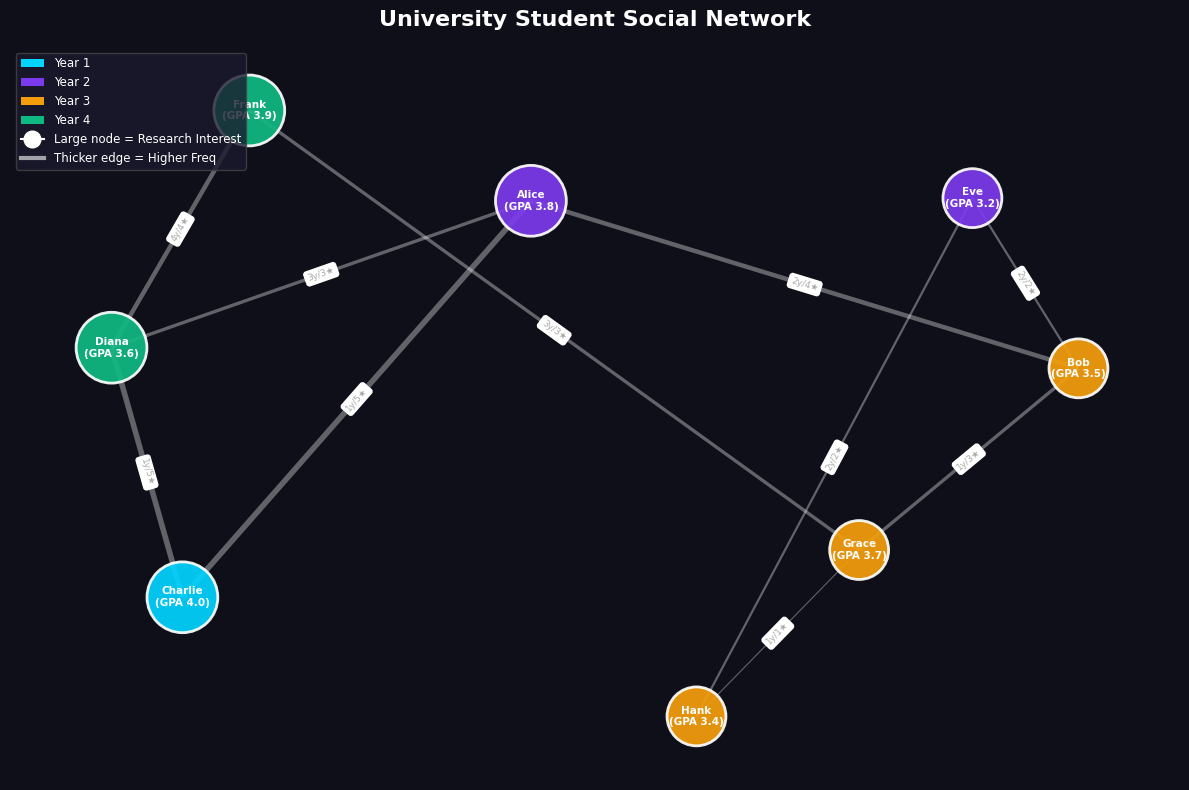

In [22]:
# 2. Visualise the Social Network

pos = nx.spring_layout(G, seed=42, k=2.2)

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

node_colors = [YEAR_COLORS[G.nodes[nd]['year']] for nd in G.nodes()]
node_sizes  = [1800 + G.nodes[nd]['research'] * 800 for nd in G.nodes()]
edge_widths = [G[u][v]['freq'] * 0.8 for u, v in G.edges()]

nx.draw_networkx_edges(G, pos, ax=ax, width=edge_widths,
                       edge_color='white', alpha=0.35)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors,
                       node_size=node_sizes, alpha=0.92,
                       linewidths=2, edgecolors='white')
labels = {nd: f"{d['name']}\n(GPA {d['gpa']:.1f})" for nd, d in G.nodes(data=True)}
nx.draw_networkx_labels(G, pos, labels, ax=ax,
                        font_size=7.5, font_color='white', font_weight='bold')
edge_labels = {(u, v): f"{d['duration']}y/{d['freq']}★" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels, ax=ax,
                              font_size=6.5, font_color='#aaaaaa')

legend_elems = [
    mpatches.Patch(facecolor=YEAR_COLORS[yr], label=f'Year {yr}') for yr in sorted(YEAR_COLORS)
] + [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='white',
           markersize=12, label='Large node = Research Interest'),
    Line2D([0], [0], linewidth=3, color='white', alpha=0.6, label='Thicker edge = Higher Freq'),
]
ax.legend(handles=legend_elems, loc='upper left',
          facecolor='#1a1a2e', edgecolor='#444', labelcolor='white', fontsize=8.5)
ax.set_title("University Student Social Network",
             color='white', fontsize=16, fontweight='bold', pad=15)
ax.axis('off')
plt.tight_layout()
plt.show()


In [23]:
# 3. Graph Matrix Representations

# ── Adjacency ──────────────────────────────────────────────────────────────
A = nx.to_numpy_array(G, nodelist=range(n), dtype=int)

# ── Degree ─────────────────────────────────────────────────────────────────
degrees = dict(G.degree())
D = np.diag([degrees[i] for i in range(n)])

# ── Incidence ──────────────────────────────────────────────────────────────
edges_list     = list(G.edges())
B              = np.zeros((n, len(edges_list)), dtype=int)
edge_col_names = [f"{STUDENTS[u][0]}-{STUDENTS[v][0]}" for u, v in edges_list]
for eidx, (u, v) in enumerate(edges_list):
    B[u, eidx] = 1
    B[v, eidx] = 1

# ── Laplacian ──────────────────────────────────────────────────────────────
L = D - A

# Normalized Laplacian
D_inv_sqrt = np.diag([1.0 / np.sqrt(D[i, i]) if D[i, i] > 0 else 0 for i in range(n)])
L_norm     = D_inv_sqrt @ L @ D_inv_sqrt

# ── Print summaries ────────────────────────────────────────────────────────
for label, mat, cols in [
    ("ADJACENCY  A",    A, names),
    ("DEGREE     D",    D, names),
    ("LAPLACIAN  L=D−A", L, names),
]:
    print("=" * 55)
    print(f" {label}")
    print("=" * 55)
    print(pd.DataFrame(mat, index=names, columns=cols).to_string())
    print()

print("=" * 70)
print(f" INCIDENCE  B  ({n} nodes × {len(edges_list)} edges)")
print("=" * 70)
print(pd.DataFrame(B, index=names, columns=edge_col_names).to_string())
print()

# Laplacian eigenvalues
eigenvalues = np.linalg.eigvalsh(L)
print(f" Eigenvalues of L: {np.round(eigenvalues, 4)}")
print(f" Fiedler value λ₁ ≈ {eigenvalues[1]:.4f}  →  "
      f"{'Connected ✅' if eigenvalues[1] > 1e-8 else 'Disconnected ❌'}")


 ADJACENCY  A
         Alice  Bob  Charlie  Diana  Eve  Frank  Grace  Hank
Alice        0    1        1      1    0      0      0     0
Bob          1    0        0      0    1      0      1     0
Charlie      1    0        0      1    0      0      0     0
Diana        1    0        1      0    0      1      0     0
Eve          0    1        0      0    0      0      0     1
Frank        0    0        0      1    0      0      1     0
Grace        0    1        0      0    0      1      0     1
Hank         0    0        0      0    1      0      1     0

 DEGREE     D
         Alice  Bob  Charlie  Diana  Eve  Frank  Grace  Hank
Alice        3    0        0      0    0      0      0     0
Bob          0    3        0      0    0      0      0     0
Charlie      0    0        2      0    0      0      0     0
Diana        0    0        0      3    0      0      0     0
Eve          0    0        0      0    2      0      0     0
Frank        0    0        0      0    0      2      0  

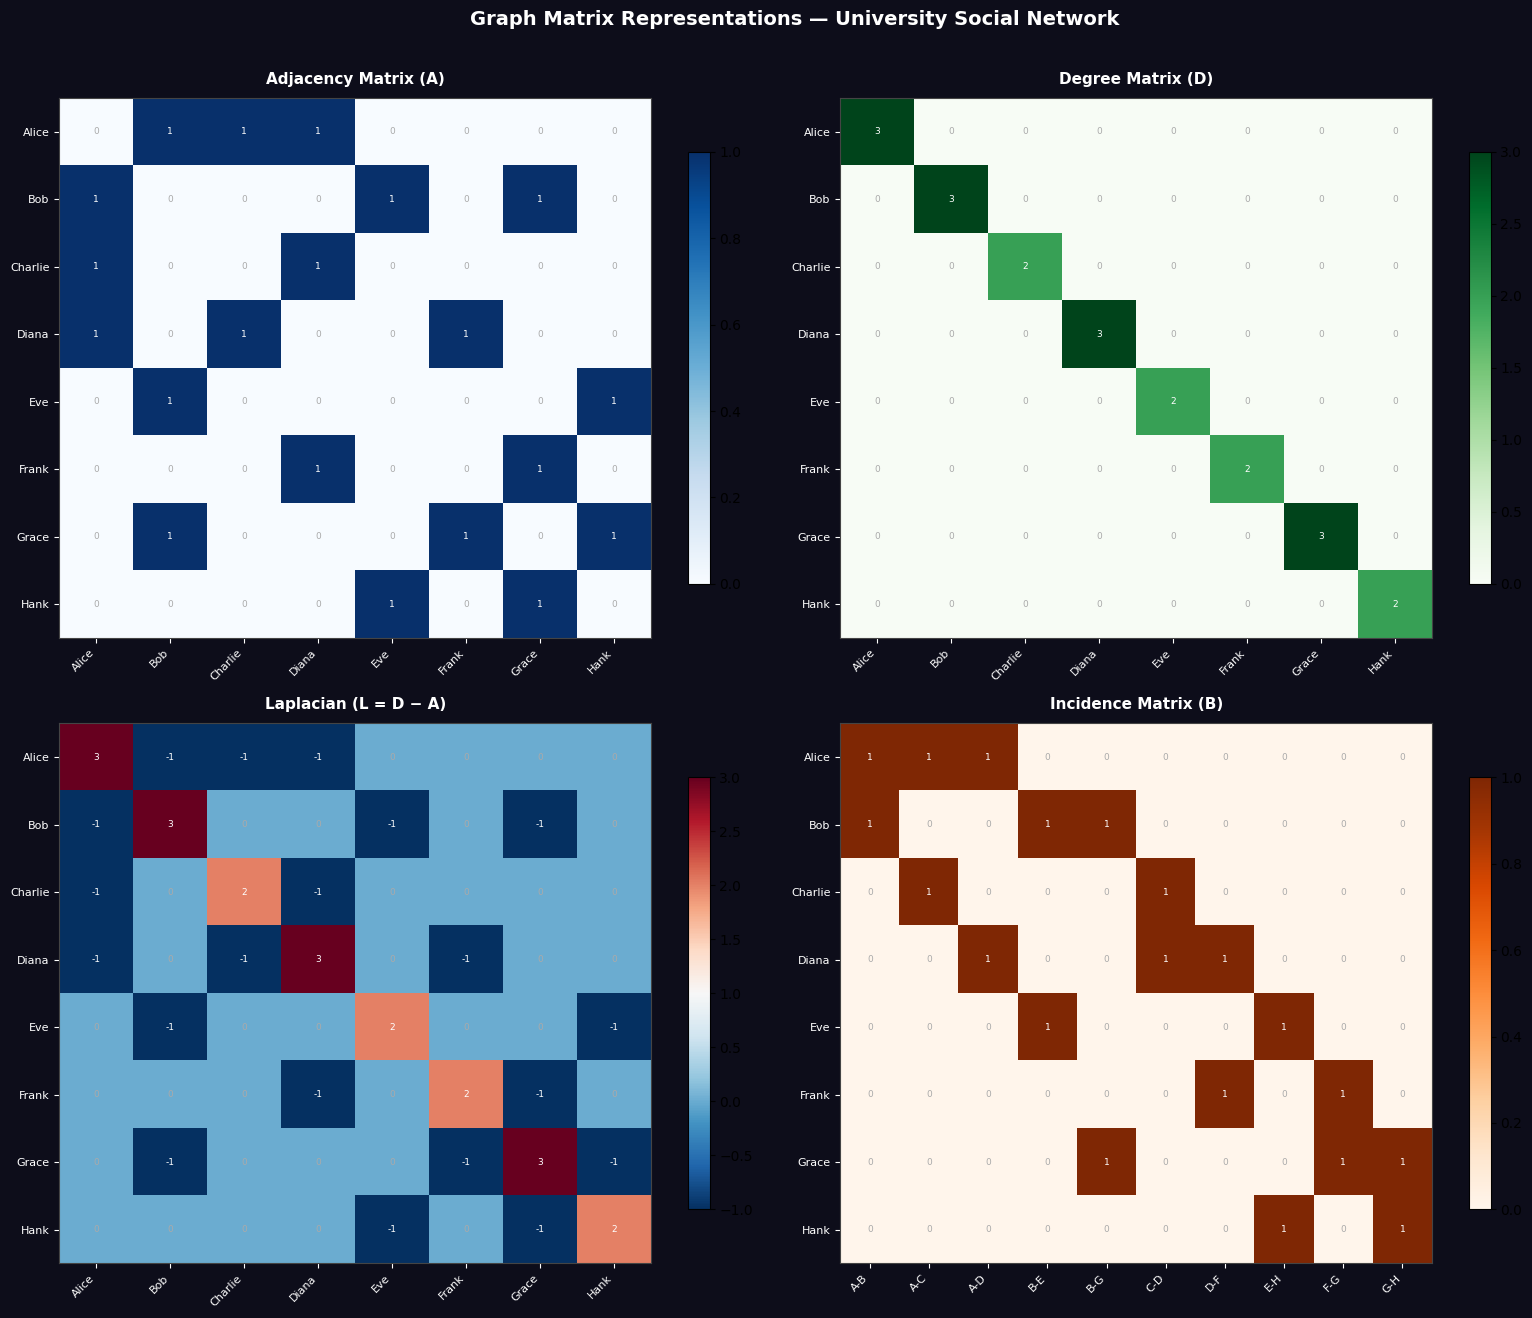

In [24]:
# 3e. Matrix Heatmaps

fig, axes = plt.subplots(2, 2, figsize=(16, 13))
fig.patch.set_facecolor('#0d0d1a')

matrix_specs = [
    (A, "Adjacency Matrix (A)",        'Blues',   names,          names),
    (D, "Degree Matrix (D)",           'Greens',  names,          names),
    (L, "Laplacian (L = D − A)",       'RdBu_r',  names,          names),
    (B, "Incidence Matrix (B)",        'Oranges', names,          edge_col_names),
]

for ax, (mat, title, cmap, rlabels, clabels) in zip(axes.flat, matrix_specs):
    ax.set_facecolor('#0d0d1a')
    im = ax.imshow(mat, cmap=cmap, aspect='auto')
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set(xticks=range(len(clabels)), yticks=range(len(rlabels)))
    ax.set_xticklabels(clabels, rotation=45, ha='right', fontsize=8, color='white')
    ax.set_yticklabels(rlabels, fontsize=8, color='white')
    ax.set_title(title, color='white', fontsize=11, fontweight='bold', pad=10)
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444')
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val  = mat[i, j]
            text = f"{val:.1f}" if isinstance(val, float) else str(val)
            ax.text(j, i, text, ha='center', va='center',
                    fontsize=6.5, color='white' if abs(val) > 0.5 else '#aaa')

fig.suptitle("Graph Matrix Representations — University Social Network",
             color='white', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [25]:
# 4. Build PyG Data Object and GCN Model

# ── Node feature tensor (normalized) ─────────────────────────────────────
X      = torch.tensor([NODE_FEATURES[i] for i in range(n)], dtype=torch.float)
X_norm = (X - X.mean(0)) / (X.std(0) + 1e-8)

# ── Edge index in COO format (both directions for undirected graph) ───────
ei_list, ea_list = [], []
for src, dst, feat in EDGES:
    for s, d in [(src, dst), (dst, src)]:
        ei_list.append([s, d])
        ea_list.append([feat['duration'], feat['freq']])

edge_index = torch.tensor(ei_list, dtype=torch.long).t().contiguous()
edge_attr  = torch.tensor(ea_list, dtype=torch.float)

data = Data(x=X_norm, edge_index=edge_index, edge_attr=edge_attr, num_nodes=n)

print("PyG Data Object:", data)
print(f"  Node features : {data.x.shape}")
print(f"  Edge index    : {data.edge_index.shape}")
print(f"  Undirected    : {data.is_undirected()}")


class GCNEncoder(nn.Module):
    """
    2-Layer Graph Convolutional Network for node embedding.

    Architecture:
        GCNConv(IN_DIM → HIDDEN_DIM) + ReLU + Dropout   [Layer 1]
        GCNConv(HIDDEN_DIM → EMBED_DIM)                  [Layer 2]

    GCN Update Rule:
        H^(l+1) = σ( D̃^(-1/2) Ã D̃^(-1/2) H^(l) W^(l) ),  Ã = A + I
    """

    def __init__(self, in_channels: int, hidden_channels: int, out_channels: int):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        h1 = F.relu(self.conv1(x, edge_index))
        h1 = F.dropout(h1, p=DROPOUT, training=self.training)
        h2 = self.conv2(h1, edge_index)
        return h1, h2   # both layers returned for inspection


model = GCNEncoder(IN_DIM, HIDDEN_DIM, EMBED_DIM)
model.eval()

print("\nGCN Architecture:")
print(model)
print(f"Total parameters: {sum(p.numel() for p in model.parameters())}")


PyG Data Object: Data(x=[8, 4], edge_index=[2, 20], edge_attr=[20, 2], num_nodes=8)
  Node features : torch.Size([8, 4])
  Edge index    : torch.Size([2, 20])
  Undirected    : True

GCN Architecture:
GCNEncoder(
  (conv1): GCNConv(4, 8)
  (conv2): GCNConv(8, 4)
)
Total parameters: 76


 NODE EMBEDDINGS (2 rounds of message passing)
 Layer 1  shape: torch.Size([8, 8])         (n_nodes × 8)
 Layer 2  shape: torch.Size([8, 4])         (n_nodes × 4)

 Node     Name       Embedding (4D)
 --------------------------------------------------------
 0        Alice      [+0.1142, -0.4430, -0.4519, -0.3330]
 1        Bob        [-0.3965, -0.0951, -0.3537, -0.5447]
 2        Charlie    [+0.2076, -0.4619, -0.5027, -0.2969]
 3        Diana      [+0.0761, -0.5045, -0.6231, -0.4032]
 4        Eve        [-0.5568, -0.1172, -0.2468, -0.6479]
 5        Frank      [-0.1879, -0.2584, -0.5848, -0.4520]
 6        Grace      [-0.4935, -0.1046, -0.4337, -0.5922]
 7        Hank       [-0.6378, +0.0043, -0.3874, -0.7305]

 Most similar pair: Bob ↔ Grace (cosine similarity = 0.9979)


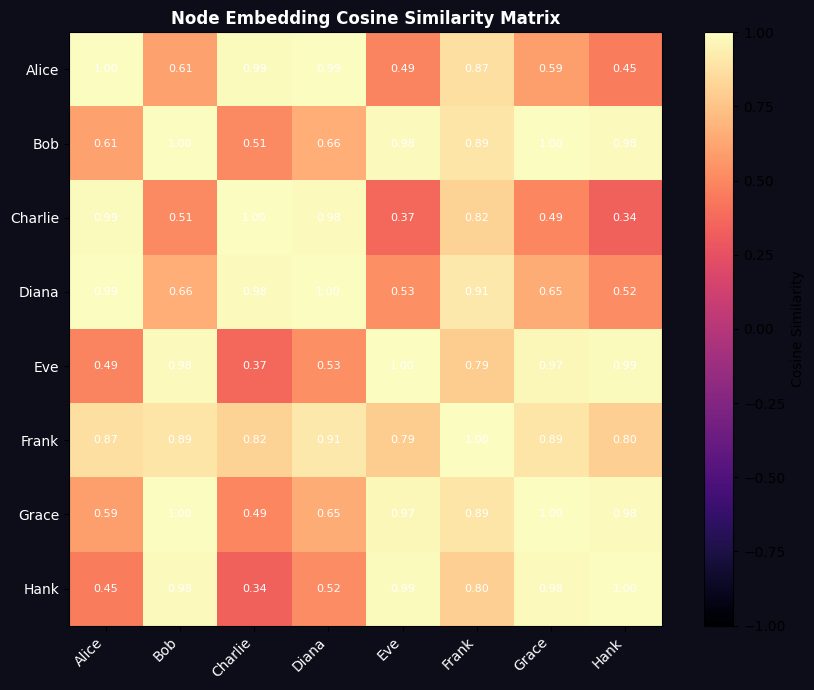

In [26]:
# 5. Forward Pass — Obtain Node Embeddings

with torch.no_grad():
    h1, embeddings = model(data.x, data.edge_index)

print("=" * 58)
print(" NODE EMBEDDINGS (2 rounds of message passing)")
print("=" * 58)
print(f" Layer 1  shape: {h1.shape}         (n_nodes × {HIDDEN_DIM})")
print(f" Layer 2  shape: {embeddings.shape}         (n_nodes × {EMBED_DIM})")
print()
print(f" {'Node':<8} {'Name':<10} {'Embedding (4D)'}")
print(" " + "-"*56)
for i in range(n):
    emb_str = "[" + ", ".join(f"{v:+.4f}" for v in embeddings[i].numpy()) + "]"
    print(f" {i:<8} {STUDENTS[i]:<10} {emb_str}")

# ── Cosine similarity matrix ──────────────────────────────────────────────
from torch.nn.functional import cosine_similarity

sim_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        sim_matrix[i, j] = cosine_similarity(
            embeddings[i].unsqueeze(0), embeddings[j].unsqueeze(0)
        ).item()

# Most similar pair (excluding diagonal)
sim_copy = sim_matrix.copy()
np.fill_diagonal(sim_copy, -2)
idx = np.unravel_index(np.argmax(sim_copy), sim_copy.shape)
print(f"\n Most similar pair: {names[idx[0]]} ↔ {names[idx[1]]} "
      f"(cosine similarity = {sim_copy[idx]:.4f})")

# ── PCA to 2D for visualisation ───────────────────────────────────────────
pca     = PCA(n_components=2).fit(embeddings.numpy())
emb_2d  = pca.transform(embeddings.numpy())
var_exp = pca.explained_variance_ratio_

# ── Cosine similarity heatmap ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor('#0d0d1a')
ax.set_facecolor('#0d0d1a')
im = ax.imshow(sim_matrix, cmap='magma', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='Cosine Similarity')
ax.set(xticks=range(n), yticks=range(n))
ax.set_xticklabels(names, rotation=45, ha='right', color='white')
ax.set_yticklabels(names, color='white')
for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{sim_matrix[i, j]:.2f}", ha='center', va='center',
                fontsize=8, color='white')
ax.set_title("Node Embedding Cosine Similarity Matrix",
             color='white', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


In [28]:
# 6. Interactive Gradio Dashboard

import io, base64
import matplotlib
matplotlib.use('Agg')   # non-interactive backend for Gradio

# ── Helper: figure → base64 PNG ──────────────────────────────────────────
def fig_to_b64(fig) -> str:
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=120, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.close(fig)
    return "data:image/png;base64," + base64.b64encode(buf.getvalue()).decode()


# ── Tab 1: Network Explorer ──────────────────────────────────────────────
def plot_network(highlight_node: str) -> str:
    target = next((k for k, v in STUDENTS.items() if v == highlight_node), None)

    fig, ax = plt.subplots(figsize=(10, 7))
    fig.patch.set_facecolor(BG_COLOR)
    ax.set_facecolor(BG_COLOR)

    hop1 = set(G.neighbors(target)) if target is not None else set()

    colors = []
    for nd in G.nodes():
        if nd == target:
            colors.append(COLOR_TARGET)
        elif nd in hop1:
            colors.append(COLOR_HOP1)
        else:
            colors.append(YEAR_COLORS[G.nodes[nd]['year']])

    sizes = [1800 + G.nodes[nd]['research'] * 800 for nd in G.nodes()]
    if target is not None:
        sizes[target] = 3200

    nx.draw_networkx_edges(G, pos, ax=ax, edge_color='white', alpha=0.3,
                           width=[G[u][v]['freq'] * 0.7 for u, v in G.edges()])
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors,
                           node_size=sizes, linewidths=2, edgecolors='white')
    labels = {nd: f"{d['name']}\n(Y{d['year']}, {d['gpa']:.1f})" for nd, d in G.nodes(data=True)}
    nx.draw_networkx_labels(G, pos, labels, ax=ax,
                            font_size=7, font_color='white', font_weight='bold')
    edge_labels = {(u, v): f"{d['duration']}y/{d['freq']}★" for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels, ax=ax,
                                  font_size=6, font_color='#bbb')

    title = f"Social Network — {highlight_node} highlighted" if target is not None else "Social Network"
    ax.set_title(title, color='white', fontsize=13, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    return fig_to_b64(fig)


# ── Tab 2: Matrix Viewer ─────────────────────────────────────────────────
def plot_matrix(matrix_name: str) -> str:
    matrix_map = {
        "Adjacency (A)":    (A,      names,          names,          'Blues',   "A[i][j] = 1 if edge exists"),
        "Degree (D)":       (D,      names,          names,          'Greens',  "D[i][i] = degree of node i"),
        "Laplacian (L=D−A)":(L,      names,          names,          'RdBu_r',  "L = D − A"),
        "Incidence (B)":    (B,      names,          edge_col_names, 'Oranges', "B[i][e] = 1 if node i in edge e"),
    }
    mat, rlabels, clabels, cmap, subtitle = matrix_map[matrix_name]
    fig, ax = plt.subplots(figsize=(10, 7))
    fig.patch.set_facecolor('#0d0d1a')
    ax.set_facecolor('#0d0d1a')
    im = ax.imshow(mat, cmap=cmap, aspect='auto')
    plt.colorbar(im, ax=ax, shrink=0.85)
    ax.set(xticks=range(len(clabels)), yticks=range(len(rlabels)))
    ax.set_xticklabels(clabels, rotation=45, ha='right', fontsize=9, color='white')
    ax.set_yticklabels(rlabels, fontsize=9, color='white')
    ax.set_title(f"{matrix_name}\n{subtitle}", color='white', fontsize=12, fontweight='bold')
    ax.tick_params(colors='white')
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val  = mat[i, j]
            text = f"{val:.2f}" if isinstance(val, float) else str(val)
            ax.text(j, i, text, ha='center', va='center',
                    fontsize=7, color='white' if abs(val) > 0.4 else '#888')
    plt.tight_layout()
    return fig_to_b64(fig)


# ── Tab 3: Embedding Space ───────────────────────────────────────────────
def plot_embeddings(highlight_node: str) -> str:
    target = next((k for k, v in STUDENTS.items() if v == highlight_node), None)
    hop1   = set(G.neighbors(target)) if target is not None else set()

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.patch.set_facecolor('#0a0a16')

    # Left: PCA scatter
    ax = axes[0]
    ax.set_facecolor('#0a0a16')
    colors = [COLOR_TARGET if i == target else COLOR_HOP1 if i in hop1 else '#0ea5e9' for i in range(n)]
    sizes  = [280 if i == target else 140 for i in range(n)]
    ax.scatter(emb_2d[:, 0], emb_2d[:, 1], c=colors, s=sizes,
               edgecolors='white', linewidths=1.5, zorder=5)
    for i in range(n):
        ax.annotate(STUDENTS[i], (emb_2d[i, 0], emb_2d[i, 1]),
                    textcoords='offset points', xytext=(8, 5),
                    fontsize=9, color='white', fontweight='bold')
    for u, v in G.edges():
        ax.plot([emb_2d[u, 0], emb_2d[v, 0]], [emb_2d[u, 1], emb_2d[v, 1]],
                color='white', alpha=0.12, linewidth=1)
    ax.set_title(f"Node Embeddings (PCA — {var_exp[0]*100:.1f}% + {var_exp[1]*100:.1f}% var)",
                 color='white', fontsize=11, fontweight='bold')
    ax.tick_params(colors='white')
    ax.set_xlabel("PC 1", color='#aaa'); ax.set_ylabel("PC 2", color='#aaa')
    ax.grid(True, alpha=0.1, color='white')
    for sp in ax.spines.values(): sp.set_edgecolor('#333')

    # Right: cosine similarity heatmap
    ax2 = axes[1]
    ax2.set_facecolor('#0a0a16')
    im = ax2.imshow(sim_matrix, cmap='magma', vmin=-1, vmax=1)
    plt.colorbar(im, ax=ax2, label='Cosine Similarity')
    ax2.set(xticks=range(n), yticks=range(n))
    ax2.set_xticklabels(names, rotation=45, ha='right', color='white', fontsize=8)
    ax2.set_yticklabels(names, color='white', fontsize=8)
    for i in range(n):
        for j in range(n):
            ax2.text(j, i, f"{sim_matrix[i, j]:.2f}", ha='center', va='center',
                     fontsize=7, color='white')
    ax2.set_title("Cosine Similarity Matrix", color='white', fontsize=11, fontweight='bold')

    plt.tight_layout()
    return fig_to_b64(fig)


# ── Tab 4: Node Inspector ────────────────────────────────────────────────
def inspect_node(node_name: str) -> tuple:
    nid    = next(k for k, v in STUDENTS.items() if v == node_name)
    d      = G.nodes[nid]
    hop1   = list(G.neighbors(nid))
    hop2   = set()
    for nb in hop1:
        hop2.update(G.neighbors(nb))
    hop2.discard(nid)
    hop2 -= set(hop1)

    emb     = embeddings[nid].numpy()
    h1_emb  = h1[nid].numpy()
    feat    = data.x[nid].numpy()

    info = f"""
## {node_name} — Node {nid}

**Features (raw):** Age={d['age']}, GPA={d['gpa']:.1f}, Year={d['year']}, Research={'Yes' if d['research'] else 'No'}
**Degree:** {G.degree(nid)} connections

**1-hop neighbours:** {[STUDENTS[nb] for nb in hop1]}
**2-hop neighbours:** {[STUDENTS[nb] for nb in sorted(hop2)]}

**Normalized input features:**  `{feat.round(3)}`
**Layer 1 embedding (8D):**   `{h1_emb.round(4)}`
**Final embedding   (4D):**   `{emb.round(4)}`

**Cosine similarities with others:**
"""
    for j in range(n):
        if j == nid: continue
        bar = '█' * int(abs(sim_matrix[nid, j]) * 10)
        info += f"  - {STUDENTS[j]:<8}: {sim_matrix[nid, j]:+.4f}  {bar}\n"

    # Receptive field plot
    receptive = {nid} | set(hop1) | hop2
    subG = G.subgraph(receptive).copy()
    sub_pos = nx.spring_layout(subG, seed=7, k=2.5)
    color_map = [COLOR_TARGET if nd == nid else COLOR_HOP1 if nd in hop1 else COLOR_HOP2
                 for nd in subG.nodes()]
    size_map  = [2800 if nd == nid else 1800 if nd in hop1 else 1200 for nd in subG.nodes()]

    fig, ax = plt.subplots(figsize=(7, 5))
    fig.patch.set_facecolor('#0a0a16')
    ax.set_facecolor('#0a0a16')
    nx.draw_networkx_edges(subG, sub_pos, ax=ax, edge_color='white', alpha=0.4, width=1.8)
    nx.draw_networkx_nodes(subG, sub_pos, ax=ax, node_color=color_map,
                           node_size=size_map, linewidths=2.5, edgecolors='white')
    nx.draw_networkx_labels(subG, sub_pos, {nd: STUDENTS[nd] for nd in subG.nodes()},
                            ax=ax, font_size=9, font_color='white', font_weight='bold')
    legend = [
        mpatches.Patch(color=COLOR_TARGET, label=f'{node_name} (target)'),
        mpatches.Patch(color=COLOR_HOP1,   label='1-hop neighbours'),
        mpatches.Patch(color=COLOR_HOP2,   label='2-hop neighbours'),
    ]
    ax.legend(handles=legend, loc='lower left', facecolor='#1a1a2e',
              edgecolor='#555', labelcolor='white', fontsize=8)
    ax.set_title(f"Receptive Field of {node_name} (2-layer GCN)",
                 color='white', fontsize=11, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()

    return info, fig_to_b64(fig)


# ── Build Dashboard ──────────────────────────────────────────────────────
student_names = list(STUDENTS.values())

with gr.Blocks(
    title="GCN Social Network Dashboard",
    theme=gr.themes.Base(
        primary_hue="violet",
        secondary_hue="cyan",
        neutral_hue="slate",
        font=[gr.themes.GoogleFont("Inter"), "sans-serif"],
    ),
    css="""
        body { background: #0a0a14 !important; }
        .gradio-container { max-width: 1200px; margin: auto; }
        h1 { text-align: center; background: linear-gradient(135deg, #7c3aed, #00d4ff);
              -webkit-background-clip: text; -webkit-text-fill-color: transparent; }
        .tab-nav button { font-weight: 600; }
    """,
) as dashboard:

    gr.Markdown("# 🕸️ GCN Social Network Explorer")
    gr.Markdown("Explore the university student graph — matrices, embeddings, and message passing — interactively.")

    with gr.Tabs():

        # Tab 1 — Network
        with gr.TabItem("🌐 Network"):
            gr.Markdown("### Social Network Visualisation")
            gr.Markdown("Select a student to highlight their direct neighbours.")
            with gr.Row():
                node_dd = gr.Dropdown(choices=["(none)"] + student_names,
                                      value="(none)", label="Highlight Node")
                btn_net = gr.Button("Render", variant="primary")
            net_img = gr.HTML()
            btn_net.click(
                fn=lambda x: f'<img src="{plot_network(x if x != "(none)" else None)}" style="width:100%">',
                inputs=node_dd, outputs=net_img
            )

        # Tab 2 — Matrices
        with gr.TabItem("📊 Matrices"):
            gr.Markdown("### Graph Matrix Representations")
            with gr.Row():
                mat_dd  = gr.Dropdown(
                    choices=["Adjacency (A)", "Degree (D)", "Laplacian (L=D−A)", "Incidence (B)"],
                    value="Adjacency (A)", label="Matrix"
                )
                btn_mat = gr.Button("View Matrix", variant="primary")
            mat_img = gr.HTML()
            btn_mat.click(
                fn=lambda m: f'<img src="{plot_matrix(m)}" style="width:100%">',
                inputs=mat_dd, outputs=mat_img
            )

        # Tab 3 — Embeddings
        with gr.TabItem("🧠 Embeddings"):
            gr.Markdown("### Learned Node Embeddings (PCA) + Cosine Similarity")
            with gr.Row():
                emb_dd  = gr.Dropdown(choices=["(none)"] + student_names,
                                      value="(none)", label="Highlight Node")
                btn_emb = gr.Button("Render", variant="primary")
            emb_img = gr.HTML()
            btn_emb.click(
                fn=lambda x: f'<img src="{plot_embeddings(x if x != "(none)" else None)}" style="width:100%">',
                inputs=emb_dd, outputs=emb_img
            )

        # Tab 4 — Node Inspector
        with gr.TabItem("🔍 Node Inspector"):
            gr.Markdown("### Per-node Features, Embeddings & Receptive Field")
            with gr.Row():
                insp_dd  = gr.Dropdown(choices=student_names, value="Alice", label="Select Student")
                btn_insp = gr.Button("Inspect", variant="primary")
            with gr.Row():
                insp_md  = gr.Markdown()
                insp_img = gr.HTML()
            btn_insp.click(
                fn=lambda x: (inspect_node(x)[0],
                              f'<img src="{inspect_node(x)[1]}" style="width:100%">'),
                inputs=insp_dd, outputs=[insp_md, insp_img]
            )

dashboard.launch(share=True)


/tmp/ipykernel_6027/848129406.py:202: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(
/tmp/ipykernel_6027/848129406.py:202: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f1dc28944ff9ccf06c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
